# Radar tutorial 4 — rainfall maps from sensors, compared with MRMS

**What you'll learn:** how to turn point and path sensors into hourly rainfall maps
(IDW), check them against MRMS radar on the same grid, and quality-control CML links
before mapping. Map tools: `src/analysis/rain_maps.py`, ported from pcpn_maps.

**Recipe** (all on the MRMS-aligned 0.01° grid over the OpenMesh link area, hourly mm):
1. sensor hourly values from `radar_utils.merge_event` (same pre-processing as tutorials 2–3);
2. **IDW**: each cell = Σ wᵢ rᵢ / Σ wᵢ, wᵢ = 1/dᵢ², sensors within 10 km (CML at the path midpoint);
3. **MRMS** Pass 2 on the same cells;
4. score only cells **≤ 2 km from a sensor** — farther out, IDW is extrapolation.

Maps: **CML**, **PWS** (WU), **Gauges** (ASOS + Mesonet + PWS).
**Data:** full-period study files (local) and the MRMS cache (tutorial 1).

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 30)

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))
from analysis import radar_utils as RU, rain_maps as RM

## §1. Load and merge all events (≈ 2 min)

In [2]:
networks, cml, ghcn = RU.load_sensors(verbose=False)
events = RU.load_event_catalog()
merged = RU.merge_events(events, networks, cml, verbose=False)
EVENT = events[events.event == '2024-03-23_rain'].iloc[0]

## §2. Maps for one event

`build_event_maps` returns a Dataset: one hourly map per source, `MRMS`, and
`dist_<source>` (km to the nearest sensor; nearest path for CML).

In [3]:
maps = RM.build_event_maps(merged, EVENT, cml=cml)
maps

<xarray.Dataset> Size: 182kB
Dimensions:      (time: 23, lat: 29, lon: 16)
Coordinates:
  * time         (time) datetime64[ns] 184B 2024-03-23T01:00:00 ... 2024-03-2...
  * lat          (lat) float64 232B 40.58 40.59 40.59 40.6 ... 40.84 40.84 40.85
  * lon          (lon) float64 128B -74.03 -74.03 -74.02 ... -73.89 -73.89
Data variables:
    MRMS         (time, lat, lon) float32 43kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    CML          (time, lat, lon) float32 43kB 0.1106 0.1109 ... 2.566 2.566
    dist_CML     (lat, lon) float64 4kB 7.915 7.608 7.385 ... 0.5267 1.235
    PWS          (time, lat, lon) float32 43kB 0.0 0.0 0.0 ... 0.7186 0.783
    dist_PWS     (lat, lon) float64 4kB 1.955 1.12 0.3371 ... 3.195 3.572 4.089
    Gauges       (time, lat, lon) float32 43kB 0.0 0.0 0.0 ... 0.2706 0.2616
    dist_Gauges  (lat, lon) float64 4kB 1.955 1.12 0.3371 ... 2.17 1.948 2.072
Attributes:
    event:          2024-03-23_rain
    cls:            rain
    radar_product:  MultiSensor_QPE_01H_Pass2
    domain:         Domain(lat_min=40.5719, lat_max=40.8604, lon_min=-74.0437...
    units:          mm per hour (hour-ending UTC)
    idw:            defaults

## §3. Scores vs. MRMS

Pooled over all (hour, cell) pairs within 2 km of that map's sensors. `total_*` compare
per-cell event totals. Units: mean / rmse in mm h⁻¹; others unitless.

In [4]:
scores = RM.map_scores(maps, near_km=2.0)
scores[['n', 'mean_ref', 'mean_est', 'rel_bias', 'rmse', 'nrmse', 'corr', 'csi', 'total_nrmse']].round(2)

,n,mean_ref,mean_est,rel_bias,rmse,nrmse,corr,csi,total_nrmse
map,,,,,,,,,
CML,4514,3.09,6.35,1.05,6.86,2.22,0.62,0.75,1.62
PWS,7153,3.25,3.11,-0.04,1.27,0.39,0.95,0.90,0.16
Gauges,7291,3.25,3.15,-0.03,1.24,0.38,0.95,0.90,0.15


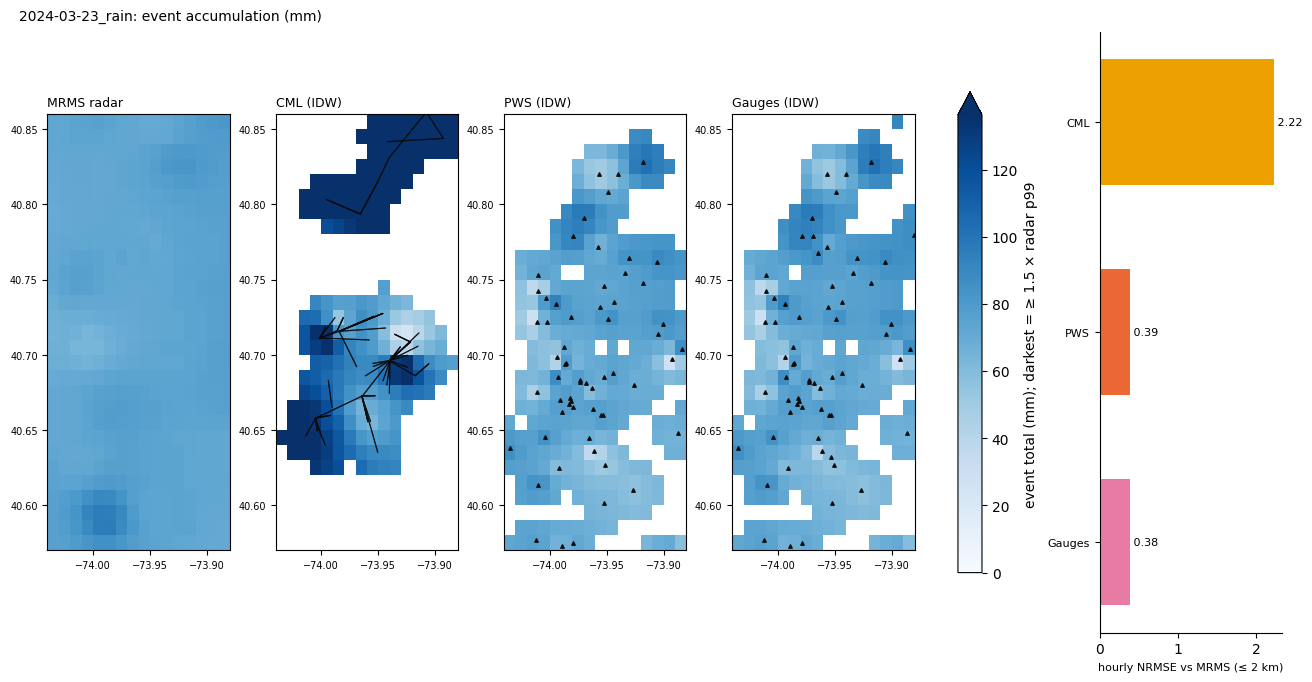

In [5]:
RM.plot_event_totals(maps, merged, cml=cml, near_km=2.0, scores=scores);

Hourly maps around the radar peak; the last row is CML minus MRMS (red = CML too
high). Note the sign flip: CML is too **low** in the peak hour (signal lost / attenuation
capped in heavy rain) and too **high** in lighter hours (wet antennas).

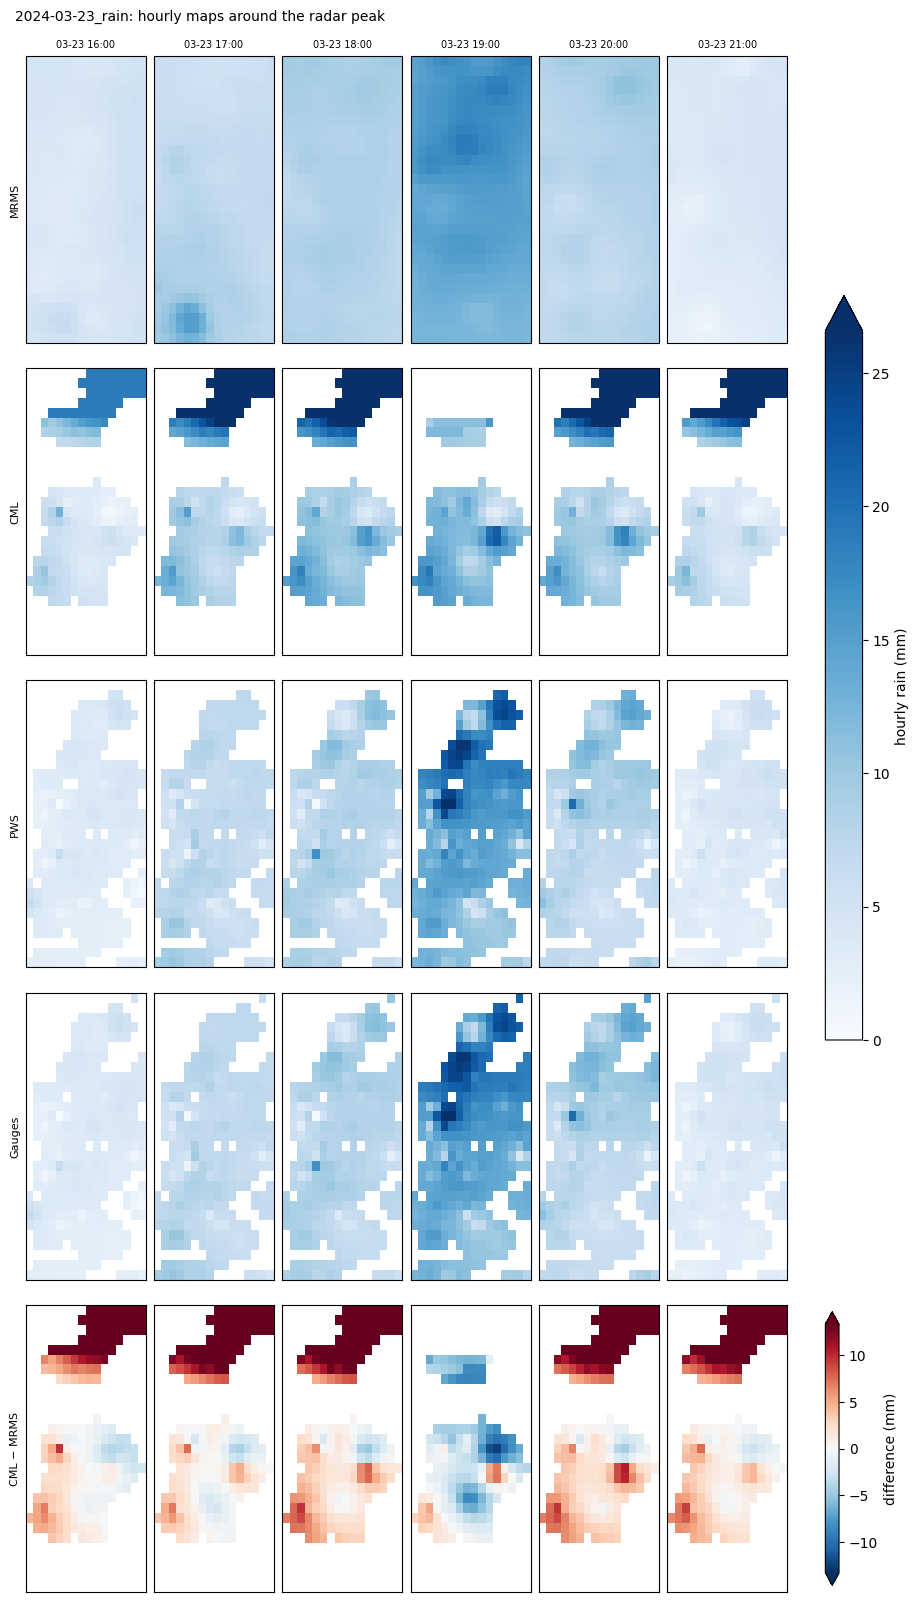

In [6]:
RM.plot_hourly_snapshots(maps, near_km=2.0);

## §4. CML quality control before mapping

`cml_retrieval_qc` compares each link's event total with the median of its neighbours
(other links within 5 km) — no radar, no gauges. It only flags; you decide what to drop.

In [7]:
qc = RM.cml_retrieval_qc(merged, EVENT.event)
display(qc.flag.value_counts().rename('links'))
flagged = qc[qc.flag.isin(['outlier', 'wet while neighbours dry'])]
flagged

flag
low coverage    82
ok              27
outlier          9
unchecked        2
Name: links, dtype: int64

,total_mm,coverage,flag,neighbour_median_mm,n_neighbours
sensor_id,,,,,
13::sublink_2,2.43,1.0,outlier,68.63,13
142::sublink_2,0.00,1.0,outlier,84.87,21
142::sublink_4,0.00,1.0,outlier,84.87,21
20::sublink_2,0.00,1.0,outlier,68.63,13
20::sublink_4,0.00,1.0,outlier,68.63,13
23::sublink_2,10.92,1.0,outlier,81.29,19
23::sublink_4,11.56,1.0,outlier,81.29,19
24::sublink_2,8.36,1.0,outlier,81.29,19
24::sublink_4,10.96,1.0,outlier,81.29,19


In [8]:
maps_qc = RM.build_event_maps(merged, EVENT, cml=cml, exclude=flagged.index)
pd.concat({'all links': RM.map_scores(maps, near_km=2.0).loc[['CML']],
           'QC-flagged removed': RM.map_scores(maps_qc, near_km=2.0).loc[['CML']]}
          )[['n', 'rel_bias', 'nrmse', 'corr', 'total_nrmse']].round(2)

,,n,rel_bias,nrmse,corr,total_nrmse
,map,,,,,
all links,CML,4514,1.05,2.22,0.62,1.62
QC-flagged removed,CML,4514,1.40,2.40,0.72,1.79


The flagged links are nearly **dead in rain** (0–12 mm among neighbours at 70–85 mm).
Removing them raises the CML map's correlation but also its bias: those links were
accidentally offsetting the others, which **over-estimate**. So QC makes the CML map
more faithful in pattern, and exposes the real problem — the retrieval's positive bias
(no wet-antenna correction).

## §5. All 15 events

Median over events of the per-event scores, by class, without and with CML QC.

In [9]:
per_event = RM.event_map_scores(merged, events, near_km=2.0, cml=cml)
per_event_qc = RM.event_map_scores(merged, events, near_km=2.0, cml=cml, qc_exclude=True)
summary = pd.concat({'no QC': RM.pool_map_scores(per_event),
                     'CML QC': RM.pool_map_scores(per_event_qc)}, names=['cml_qc'])
summary.round(2)

nrmse  rel_bias  corr   csi  total_nrmse  total_rel_bias
cml_qc cls  map                                                             
no QC  mix  CML      7.91      3.82  0.58  0.09         4.88            3.82
            Gauges   1.09     -0.05  0.80  0.65         0.23           -0.05
            PWS      1.12     -0.05  0.78  0.64         0.25           -0.05
       rain CML      2.79      1.20  0.61  0.71         1.87            1.20
            Gauges   0.69     -0.03  0.92  0.85         0.16           -0.03
            PWS      0.76     -0.03  0.90  0.85         0.17           -0.03
       snow CML      3.15      1.51  0.34  0.67         1.99            1.51
            Gauges   1.68     -0.85  0.10  0.30         0.89           -0.85
            PWS      1.77     -0.93 -0.19  0.08         0.94           -0.93
CML QC mix  CML      6.95      2.99  0.58  0.09         4.29            2.99
            Gauges   1.09     -0.05  0.80  0.65         0.23           -0.05
            PWS      1.12     -0.05  0.78  0.64         0.25           -0.05
       rain CML      2.93      1.50  0.71  0.70         2.00            1.50
            Gauges   0.69     -0.03  0.92  0.85         0.16           -0.03
            PWS      0.76     -0.03  0.90  0.85         0.17           -0.03
       snow CML      2.43      1.07  0.29  0.68         1.45            1.07
            Gauges   1.68     -0.85  0.10  0.30         0.89           -0.85
            PWS      1.77     -0.93 -0.19  0.08         0.94           -0.93

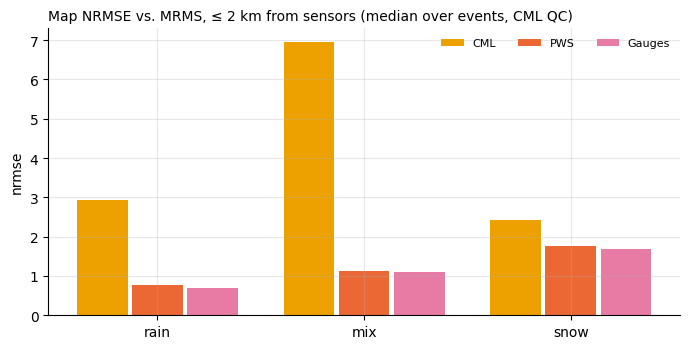

In [10]:
RU.plot_scores_by_class(RM.pool_map_scores(per_event_qc).rename_axis(['cls', 'network']),
                        'nrmse', title='Map NRMSE vs. MRMS, ≤ 2 km from sensors (median over events, CML QC)');

## §6. IDW settings

Power and number of neighbours for the rain events (CML QC on). Higher power = more local.

In [11]:
rain = events[events.cls == 'rain']
rows = []
for power in (1, 2, 3):
    for nnear in (None, 8):
        t = RM.pool_map_scores(RM.event_map_scores(merged, rain, near_km=2.0, cml=cml, qc_exclude=True,
                                                   power=power, nnear=nnear), by=('map',))
        rows.append(t.assign(power=power, nnear=nnear or 'all').reset_index())
pd.concat(rows).set_index(['map', 'power', 'nnear'])[['nrmse', 'corr', 'total_nrmse']].round(2)

,,,nrmse,corr,total_nrmse
map,power,nnear,,,
CML,1,all,2.77,0.72,1.89
Gauges,1,all,0.47,0.96,0.09
PWS,1,all,0.49,0.96,0.09
CML,1,8,3.28,0.68,2.25
Gauges,1,8,0.64,0.93,0.14
PWS,1,8,0.67,0.92,0.14
CML,2,all,2.93,0.71,2.00
Gauges,2,all,0.69,0.92,0.16
PWS,2,all,0.76,0.90,0.17


## Findings (15 events, cells ≤ 2 km from sensors, median over events)

* **Gauge maps work in rain and mix, not in snow.** PWS and all-gauge IDW maps match
  MRMS Pass 2 with NRMSE ≈ 0.7 (rain) / 1.1 (mix), event totals within ~5 %. In snow the
  unheated PWS gauges drive them to −85…−93 %.
* **CML maps inherit the retrieval bias.** +120 % (rain) and more in mix; hourly
  correlation 0.6–0.7. QC removes dead links and raises correlation but not accuracy.
  In the peak hour CML is too low (lost signal / capped attenuation), in light hours
  too high (wet antennas).
* **Smoother IDW scores better** (power 1, all neighbours: gauge NRMSE 0.47 vs 0.69 at
  power 2) — partly because MRMS is itself smooth at 1 km, so this favours smoothness
  as much as accuracy.
* **Caveat:** MRMS Pass 2 is gauge-corrected (including ASOS), so the gauge-map scores
  are optimistic; repeat §5 with `radar_product='RadarOnly_QPE_01H'` for an independent check.